#### Here, we use filtered microRNA expression data to produce designs that achieve a particular expression pattern across cell lines.

In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt

output_folder = "created_designs"
os.makedirs(output_folder, exist_ok=True)

In [22]:
# load the pre-filtered expression dataset
expression_dataset = pd.read_csv("microrna_data/merged_and_filtered_mirna_expression.csv", index_col=0)
if expression_dataset.max().max() < 10:
    expression_dataset = 10**(expression_dataset)

In [ ]:
from utils.design_utils import generate_genetic_design
# targets are specified as a dictionary of cell type to target value (1 = high expression, 0 = low expression)
# high expression in two, low in the others
target1 = {
    "HEK293T": 1,
    "MCF7": 1,
}
for cell in expression_dataset.columns:
    if cell not in target1:
        target1[cell] = 0

# emphasis is specified as a dictionary of cell type to emphasis value
# higher means the design process will prioritize achieving the target in that cell type,
# which is necessary when there are fewer target cell types than background cell types
emphasis1 = {
    "HEK293T": 3,
    "MCF7": 3,
}
for cell in expression_dataset.columns:
    if cell not in emphasis1:
        emphasis1[cell] = 1

designs1 = generate_genetic_design(
    target = target1,
    loss_emphasis = emphasis1,
    n_mirnas=5,
    mirnas=expression_dataset.index.to_list(),
    popt=[3.7],
    loss_type="mse",
    mirna_expression=expression_dataset,
    no_designs=1,
    use_combination_penalty=False,  # e.g., to filter for target-target interactions with high ddG
)

In [ ]:
# low expression in two, high in the others
target2 = {
    "SKNSH": 0,
    "HUH7": 0,
}
for cell in expression_dataset.columns:
    if cell not in target2:
        target2[cell] = 1

emphasis2 = {
    "SKNSH": 3,
    "HUH7": 3,
}
for cell in expression_dataset.columns:
    if cell not in emphasis2:
        emphasis2[cell] = 1

designs2 = generate_genetic_design(
    target = target2,
    loss_emphasis = emphasis2,
    n_mirnas=5,
    mirnas=expression_dataset.index.to_list(),
    popt=[3.7],
    loss_type="mse",
    mirna_expression=expression_dataset,
    no_designs=1,
    use_combination_penalty=False,
)

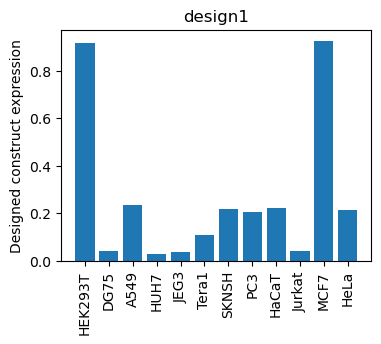

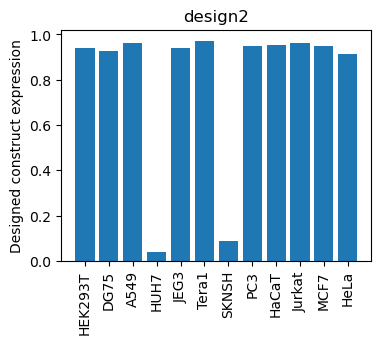

In [30]:
for designs, name in zip([designs1, designs2], ["design1", "design2"]):
    top_design = designs.iloc[0]
    cell_types = expression_dataset.columns
    plt.figure(figsize=(4,3))
    plt.bar(expression_dataset.columns, top_design[cell_types])
    plt.title(name)
    plt.xticks(rotation=90)
    plt.ylabel("Designed construct expression")
    plt.show()